# Bank Customer Churn Prediction 

## This project aims to build a classification model to predict whether a bank customer will churn. Identify the most influential features contributing to churn and develop a high-performance model to detect at-risk customers in advance.

______________________________________________________________________________________________________________________________________

## Problem Statement

### Objective

To forecast future churn (Exited) for each customer (ID) based on their informations.
This will contribute to:

・Making Strategy and approaches for future customer who will churn



### Problem Type
Classification problem

### Objective Variable (Target)
Exited:customer who churned bank

### Evaluation Metric

AUC


In [1]:
# pip install ipympl

In [2]:
# pip install prettytable

In [3]:
# pip install category_encoders

________________________________________________________________________________________________
# 1. Import libraries and dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable

from category_encoders import OneHotEncoder, GLMMEncoder, TargetEncoder, CatBoostEncoder
from sklearn import set_config
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve, make_scorer, f1_score
from sklearn.preprocessing import FunctionTransformer, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style = 'white', palette = 'viridis')
pal = sns.color_palette('viridis')

pd.set_option('display.max_rows', 100)
set_config(transform_output = 'pandas')
pd.options.mode.chained_assignment = None

import warnings
warnings.filterwarnings('ignore')


%matplotlib inline


In [5]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [6]:
import zipfile

with zipfile.ZipFile('playground-series-s4e1.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [7]:
df_submission = pd.read_csv('data/sample_submission.csv')
df_test = pd.read_csv('data/test.csv')
df_train = pd.read_csv('data/train.csv')

__________________________________________________________________________________________________
## 2. EDA

### 2-1. Detail information of each dataframes

In [8]:
print(f'Sample submission file: {df_submission.shape}\n')

print(f'Infomation :\n{df_submission.info()}')
df_submission.head()

Sample submission file: (110023, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110023 entries, 0 to 110022
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      110023 non-null  int64  
 1   Exited  110023 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 1.7 MB
Infomation :
None


,id,Exited
0,165034,0.5
1,165035,0.5
2,165036,0.5
3,165037,0.5
4,165038,0.5


In [9]:
print(f'Test file:\n{df_test.shape}\n')


print(f'Infomation :\n{df_test.info()}')
df_test.head()

Test file:
(110023, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110023 entries, 0 to 110022
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               110023 non-null  int64  
 1   CustomerId       110023 non-null  int64  
 2   Surname          110023 non-null  object 
 3   CreditScore      110023 non-null  int64  
 4   Geography        110023 non-null  object 
 5   Gender           110023 non-null  object 
 6   Age              110023 non-null  float64
 7   Tenure           110023 non-null  int64  
 8   Balance          110023 non-null  float64
 9   NumOfProducts    110023 non-null  int64  
 10  HasCrCard        110023 non-null  float64
 11  IsActiveMember   110023 non-null  float64
 12  EstimatedSalary  110023 non-null  float64
dtypes: float64(5), int64(5), object(3)
memory usage: 10.9+ MB
Infomation :
None


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00


In [10]:
print(f'Train file:\n{df_train.shape}')

print(f'Infomation :\n{df_train.info()}')
df_train.head()

Train file:
(165034, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB
Infomation :
None


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


### 2-2. Finding null values

In [11]:
files = [df_submission, df_train, df_test]
names = ['df_submission', 'df_train', 'df_test']

for name, df in zip(names, files):
    if df.isnull().sum().sum() == 0:
        print(f'{name} does not have null values.')
    else:
        print(f'{name} has null values:')
        print(df.isnull().sum())

df_submission does not have null values.
df_train does not have null values.
df_test does not have null values.


### 2-3. Finding duplicated values

In [12]:
files = [df_submission, df_train, df_test]
names = ['df_submission', 'df_train', 'df_test']

for name, df in zip(names, files):
    if df.duplicated().sum().sum() == 0:
        print(f'{name} does not have duplicated values.')
    else:
        print(f'{name} has duplicated values:')
        print(df.duplicated().sum())

df_submission does not have duplicated values.
df_train does not have duplicated values.
df_test does not have duplicated values.


### 2-4. Distribution

In [13]:
df_train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [14]:
df_test.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,110023.000000,1.100230e+05,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000
mean,220045.000000,1.569210e+07,656.530789,38.122205,4.996637,55333.611354,1.553321,0.753043,0.495233,112315.147765
std,31761.048671,7.168499e+04,80.315415,8.861550,2.806148,62788.519675,0.544714,0.431244,0.499980,50277.048244
min,165034.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,192539.500000,1.563286e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74440.325000
50%,220045.000000,1.569018e+07,660.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117832.230000
75%,247550.500000,1.575693e+07,710.000000,42.000000,7.000000,120145.605000,2.000000,1.000000,1.000000,154631.350000
max,275056.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000


### 2-5. Visualization : Distribution of target feature

In [15]:
df_train.drop(columns=["id", "CustomerId"],inplace=True)
df_test.drop(columns=["id", "CustomerId"],inplace=True)
target = 'Exited'
sns.set_palette("Set2")

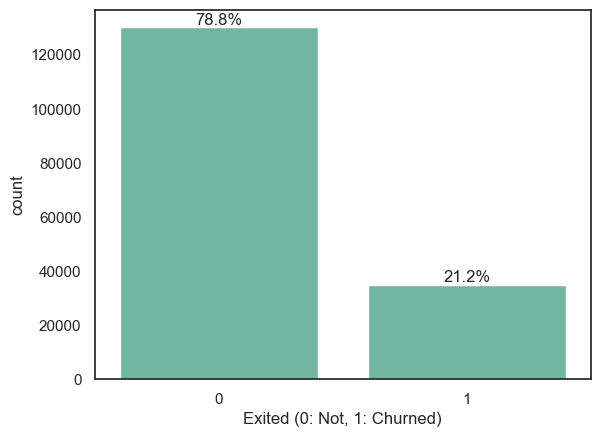

In [16]:
ax = sns.countplot(x=target, data=df_train)
ax.bar_label(ax.containers[0], labels=[f'{100 * p / len(df_train):.1f}%' for p in df_train[target].value_counts()])
plt.xlabel('Exited (0: Not, 1: Churned)')
plt.show()


### 2-6. Visualization : Distribution og all features

In [17]:
df_train.head()

train_columns = df_train.copy()
if 'Surname' in train_columns.columns:
    train_columns = train_columns.drop(columns=['Surname'])


target = 'Exited'
num_cols = train_columns.drop(target, axis=1).columns

In [18]:
train_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CreditScore      165034 non-null  int64  
 1   Geography        165034 non-null  object 
 2   Gender           165034 non-null  object 
 3   Age              165034 non-null  float64
 4   Tenure           165034 non-null  int64  
 5   Balance          165034 non-null  float64
 6   NumOfProducts    165034 non-null  int64  
 7   HasCrCard        165034 non-null  float64
 8   IsActiveMember   165034 non-null  float64
 9   EstimatedSalary  165034 non-null  float64
 10  Exited           165034 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 13.9+ MB


In [19]:
def plot_histogram(df, col, target='Exited'):
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue=target, multiple='stack', bins=30)

    try:
        mean_val = df[col].mean()
        median_val = df[col].median()
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
        plt.axvline(median_val, color='blue', linestyle='-', linewidth=1.5, label='Median')
    except:
        pass

    plt.title(f'Histgram: {col}')
    plt.xlabel(col)
    plt.ylabel('counts')
    plt.legend()
    plt.tight_layout()
    plt.show()


#### 2-6-1. Age

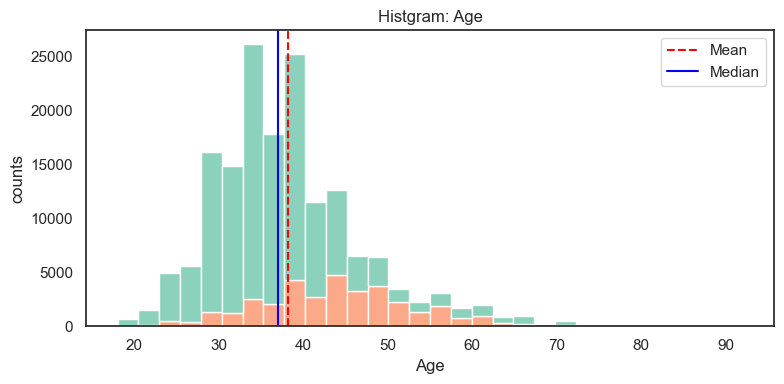

In [20]:
plot_histogram(train_columns, 'Age')

#### 2-6-2. Credit score and Balance

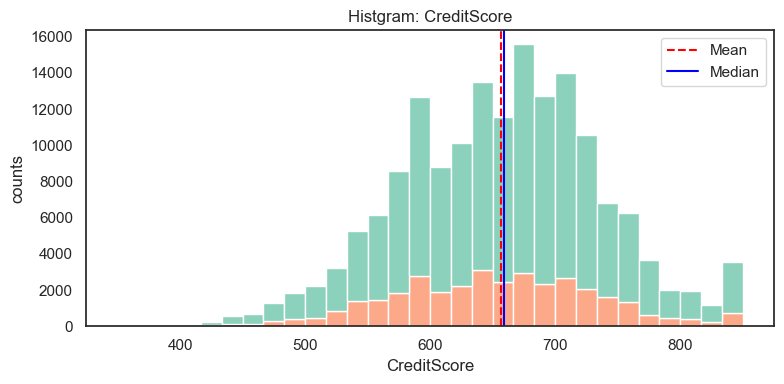

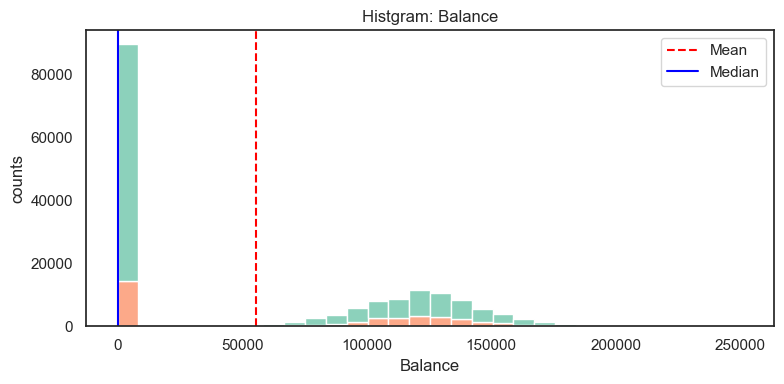

In [21]:
plot_histogram(train_columns, 'CreditScore')
plot_histogram(train_columns, 'Balance')

#### 2-6-3.Estimated Salary

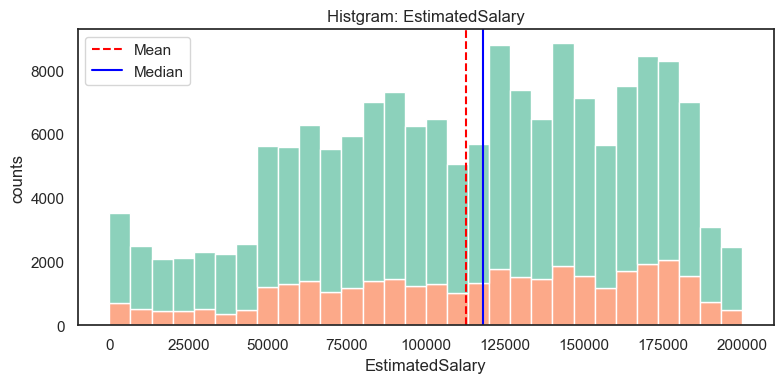

In [22]:
plot_histogram(train_columns, 'EstimatedSalary')

#### 2-6-4. Tenure

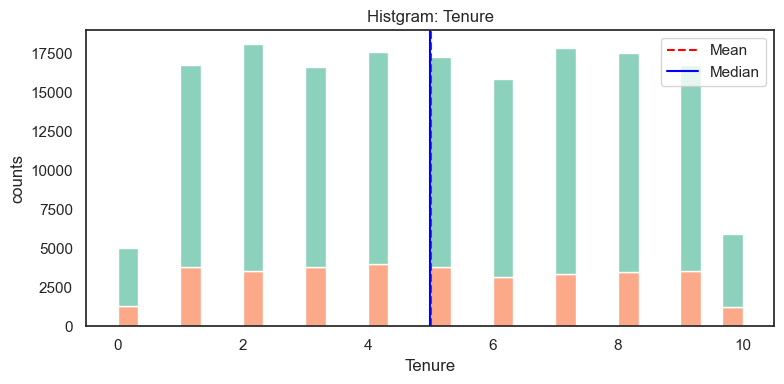

In [23]:
plot_histogram(train_columns, 'Tenure')

#### 2-6-5. Number of products and Has Credit Card and IS active member

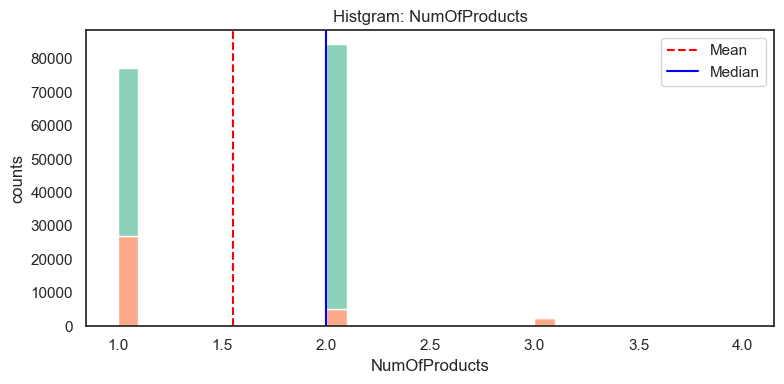

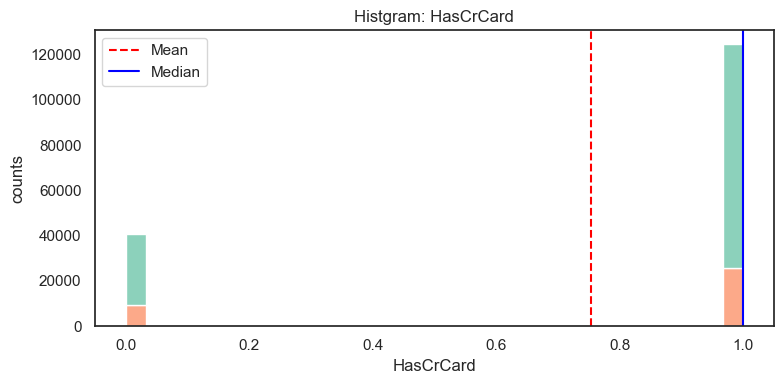

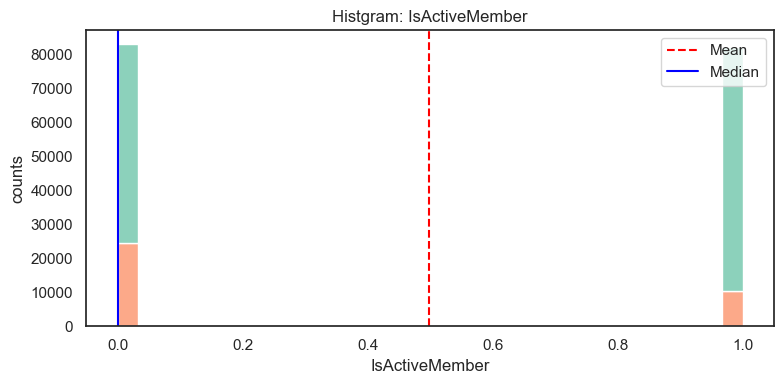

In [24]:
plot_histogram(train_columns, 'NumOfProducts')
plot_histogram(train_columns, 'HasCrCard')
plot_histogram(train_columns, 'IsActiveMember')

### Insight
・The majority of customers have either 1 or 2 products.Customers with only 1 product show a noticeably higher churn rate. So,This suggests offering more products may help reduce churn.

・It seems like most customers have a credit card.however, churn rates appear similar regardless of credit card ownership.Therefore, owning a credit card does not strongly influence churn behavior.

・For activity status, inactive members are more likely to churn.Active members are more engaged and tend to stay longer.So promoting customer engagement may be an effective churn prevention strategy.

#### 2-6-6. Gender and Country

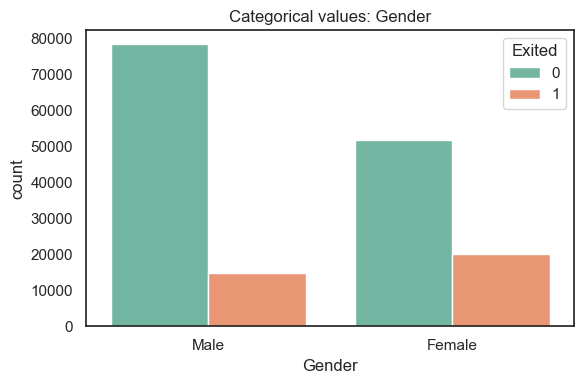

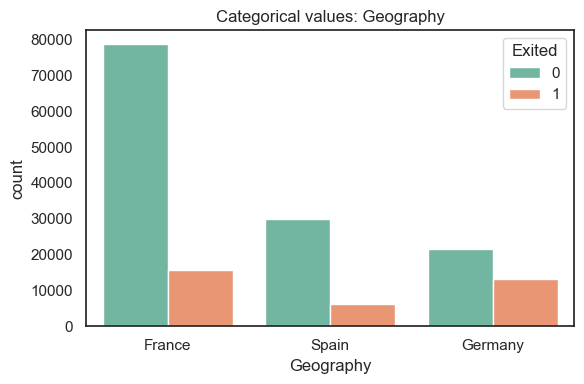

In [25]:
def plot_categorical_count(df, col, target='Exited'):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue=target)
    plt.title(f'Categorical values: {col}')
    plt.tight_layout()
    plt.show()


plot_categorical_count(train_columns, 'Gender')
plot_categorical_count(train_columns, 'Geography')

### Insight
・Overall, men have more customers, but the churn rate tends to be higher for women.

・Geographically, France has the largest number of customers, followed by Spain and Germany.
Of these, the churn rate in Germany is almost half.

___________________________________________________________________________________________________________
## 3. Feature Engineering

In [26]:
# Create a new binary feature 'ZeroBalance'
df_train['ZeroBalance'] = (df_train['Balance'] == 0).astype(int)
df_test['ZeroBalance'] = (df_test['Balance'] == 0).astype(int)

### 3-1. TFIDF-PCA (Text Transformation) for Surname

In [27]:
# pip install wordcloud

In [28]:
len(df_train['Surname'].unique())

2797

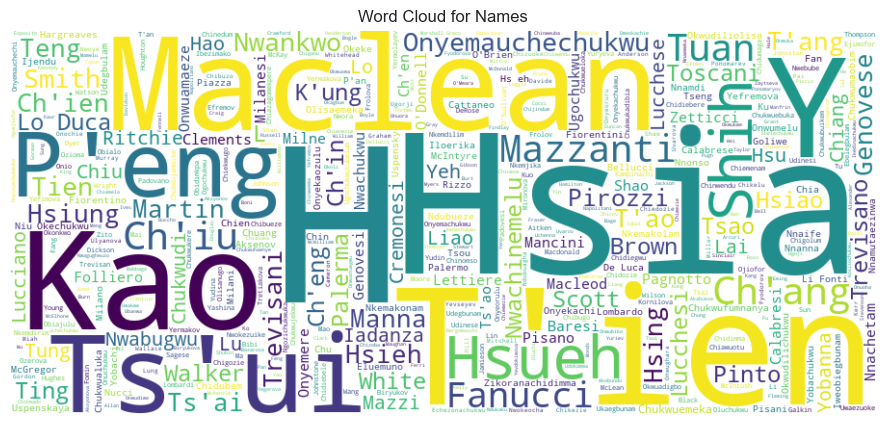

In [29]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=900, height=400, max_words=600, background_color='white').generate(' '.join(df_train['Surname']))

# Display the WordCloud
plt.figure(figsize=(20, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Names')
plt.show()


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [31]:
def tf_idf(df_train, df_test, column,n,p):
    vectorizer=TfidfVectorizer(max_features=n)
    vectors_train=vectorizer.fit_transform(df_train[column])
    vectors_test=vectorizer.transform(df_test[column])
    
    svd=TruncatedSVD(p)
    x_pca_train=svd.fit_transform(vectors_train)
    x_pca_test=svd.transform(vectors_test)
    tfidf_df_train=pd.DataFrame(x_pca_train)
    tfidf_df_test=pd.DataFrame(x_pca_test)

    
    cols=[(column+"_tfidf_"+str(f)) for f in tfidf_df_train.columns]
    tfidf_df_train.columns=cols
    tfidf_df_test.columns=cols
    df_train=pd.concat([df_train,tfidf_df_train], axis="columns")
    df_test=pd.concat([df_test,tfidf_df_test], axis="columns")
    
    return df_train, df_test

df_train,df_test=tf_idf(df_train,df_test,"Surname",1000,5)
df_train.drop(columns=["Surname"], inplace=True)
df_test.drop(columns=["Surname"], inplace=True)


In [32]:
df_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,Surname_tfidf_truncatedsvd0,Surname_tfidf_truncatedsvd1,Surname_tfidf_truncatedsvd2,Surname_tfidf_truncatedsvd3,Surname_tfidf_truncatedsvd4
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0,1,3.937698e-08,0.000001,-8.491078e-08,-0.000003,3.233345e-07
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0,1,1.437134e-07,0.000001,-3.776483e-06,-0.000001,-8.703505e-06
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0,1,3.888388e-04,0.000269,-3.851359e-03,-0.001652,-1.951353e-02
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,-7.984072e-05,-0.000738,1.378893e-03,0.004126,1.361262e-02
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0,1,-1.720401e-08,0.000001,-1.183580e-06,-0.000001,-4.006197e-07


In [33]:
df_test.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,ZeroBalance,Surname_tfidf_truncatedsvd0,Surname_tfidf_truncatedsvd1,Surname_tfidf_truncatedsvd2,Surname_tfidf_truncatedsvd3,Surname_tfidf_truncatedsvd4
0,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75,1,0.000009,0.000047,0.000028,0.000048,0.000040
1,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27,1,0.000000,0.000000,0.000000,0.000000,0.000000
2,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09,1,0.000000,0.000000,0.000000,0.000000,0.000000
3,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57,1,-0.000001,-0.000034,0.000026,0.000096,0.000055
4,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00,0,0.000000,0.000000,0.000000,0.000000,0.000000


## 3-2. External data

In [34]:
cet_bycountry = pd.read_csv('data/External_data_ECB/cet1_avg_2016.csv') 
cet_bycountry.head()

,Geography,avg_cet1_capital_2016
0,Spain,195.532700
1,Germany,192.661475
2,France,316.698050


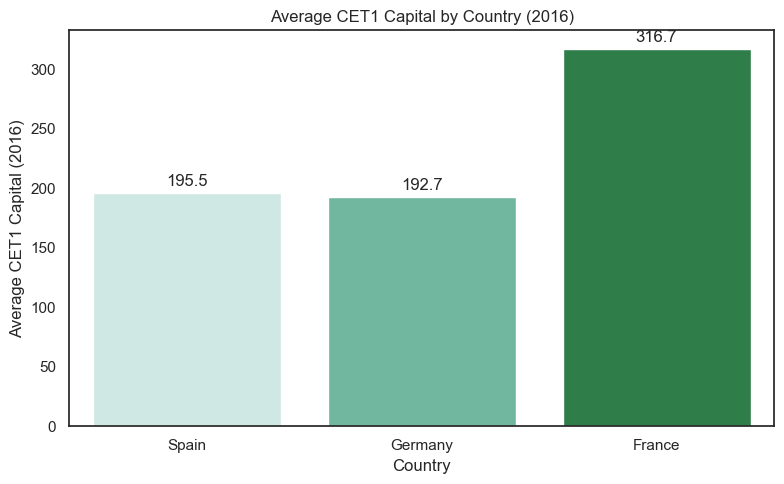

In [35]:
plt.figure(figsize=(8, 5))
bars = sns.barplot(
    data=cet_bycountry,
    x='Geography',
    y='avg_cet1_capital_2016',
    palette = "BuGn"
)


plt.xlabel('Country')
plt.ylabel('Average CET1 Capital (2016)')
plt.title('Average CET1 Capital by Country (2016)')


for container in bars.containers:
    bars.bar_label(container, fmt='%.1f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

#### Insight
 Comparing the churn rate by country with the external variable CET1, Germany has the highest churn rate. This may be related to the low CET1 values, which are unstable due to low bank reliability.

In [36]:
df_train = pd.merge(df_train, cet_bycountry, how='left', on='Geography')
df_test = pd.merge(df_test, cet_bycountry, how='left', on='Geography')
df_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,Surname_tfidf_truncatedsvd0,Surname_tfidf_truncatedsvd1,Surname_tfidf_truncatedsvd2,Surname_tfidf_truncatedsvd3,Surname_tfidf_truncatedsvd4,avg_cet1_capital_2016
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0,1,3.937698e-08,0.000001,-8.491078e-08,-0.000003,3.233345e-07,316.69805
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0,1,1.437134e-07,0.000001,-3.776483e-06,-0.000001,-8.703505e-06,316.69805
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0,1,3.888388e-04,0.000269,-3.851359e-03,-0.001652,-1.951353e-02,316.69805
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,-7.984072e-05,-0.000738,1.378893e-03,0.004126,1.361262e-02,316.69805
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0,1,-1.720401e-08,0.000001,-1.183580e-06,-0.000001,-4.006197e-07,195.53270


### 3-2. Encoding categorical feature

In [37]:

categorical_features = ['Geography', 'Gender']


df_train = pd.get_dummies(df_train, columns=categorical_features, drop_first=True)
df_test = pd.get_dummies(df_test, columns=categorical_features, drop_first=True)

## Correlation map

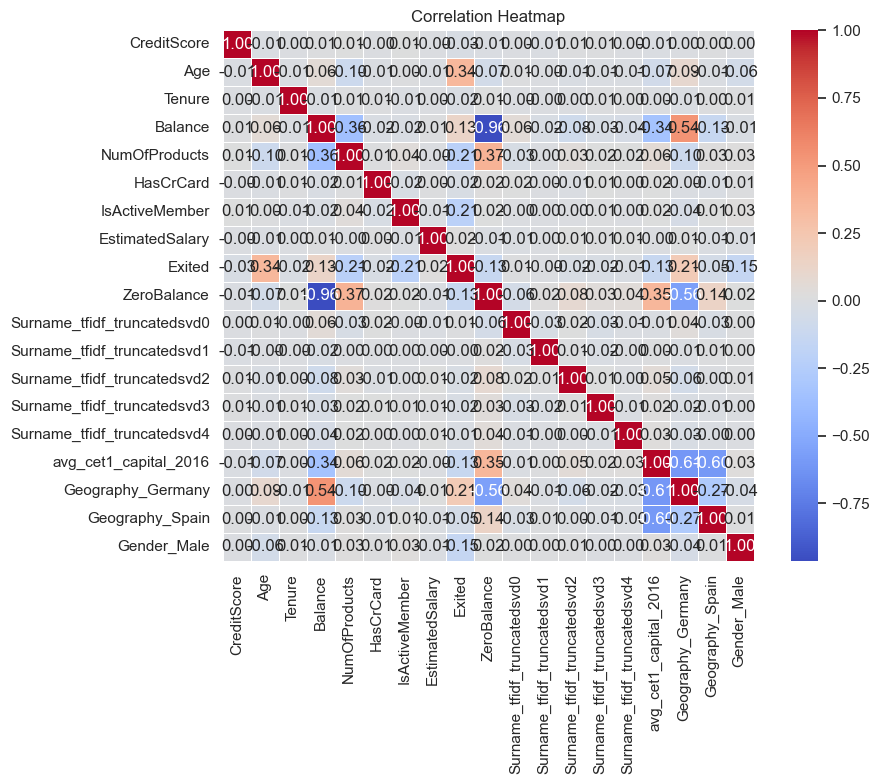

In [38]:
def plot_correlation_heatmap(df, figsize=(10, 8)):

    corr = df.corr(numeric_only=True)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        square=True,
        linewidths=0.5,
        cbar=True 
    )
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
    
plot_correlation_heatmap(df_train)

### 3-3. Handling outliers

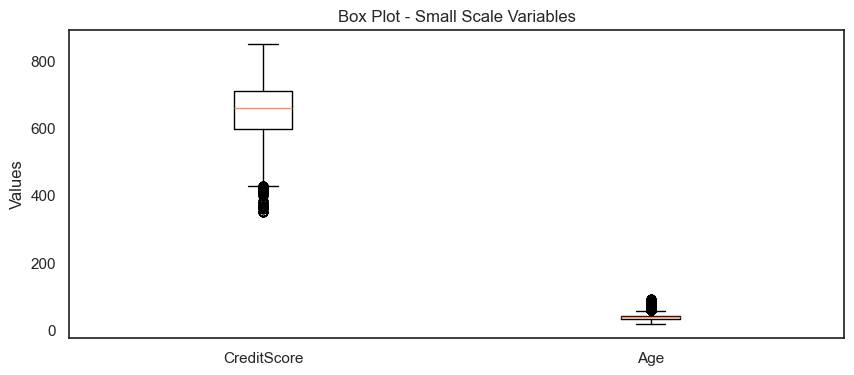

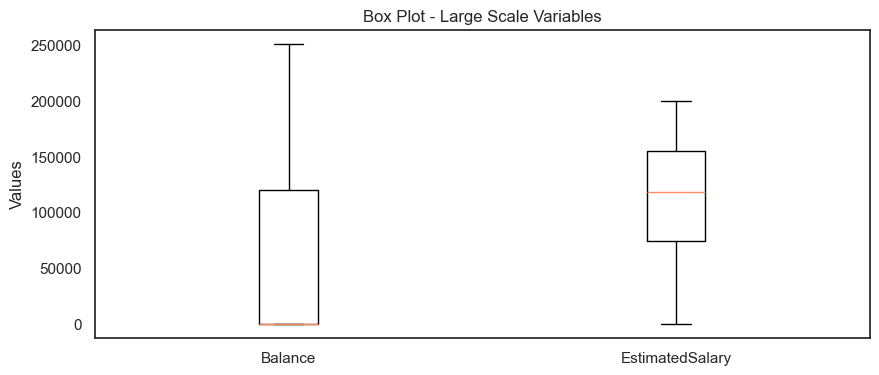

In [39]:

small_scale_cols = ['CreditScore', 'Age']
large_scale_cols = ['Balance', 'EstimatedSalary']


plt.figure(figsize=(10, 4))
plt.boxplot([df_train[col] for col in small_scale_cols], labels=small_scale_cols)
plt.title('Box Plot - Small Scale Variables')
plt.ylabel('Values')
plt.show()


plt.figure(figsize=(10, 4))
plt.boxplot([df_train[col] for col in large_scale_cols], labels=large_scale_cols)
plt.title('Box Plot - Large Scale Variables')
plt.ylabel('Values')
plt.show()


In [40]:
# pip install sweetviz

In [41]:
# pip install --upgrade ipywidgets

## 3-4. Visualization by sweetviz

In [42]:
# import sweetviz as sv
# report = sv.compare([df_train, "Train Data"], [df_test, "Test Data"])


In [43]:
# report.show_notebook(w="100%", h="full")

_________________________________________________________________________________________________________
## 4. Modeling

In [44]:
# Select X and y
X = df_train.drop(columns=['Exited'])
y = df_train['Exited']

In [45]:
from sklearn.preprocessing import LabelEncoder

# Label encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


## 4-1. XGboost

In [46]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score



def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 1200, 1400),
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.022),
        'max_depth': trial.suggest_int('max_depth', 5, 7),
        'subsample': trial.suggest_float('subsample', 0.65, 0.75),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.42, 0.47),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 7),
        'tree_method': 'hist',
        'eval_metric': 'auc',
        'verbosity': 0,
        'random_state': 42
    }

    xgb_model = XGBClassifier(**params)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc = cross_val_score(xgb_model, X, y, scoring='roc_auc', cv=skf).mean()

    return auc


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)



[I 2025-05-30 11:08:24,007] A new study created in memory with name: no-name-82ddd24d-7009-4d6a-a9c8-6a4c97b5a882
[I 2025-05-30 11:10:04,243] Trial 0 finished with value: 0.8946647310202138 and parameters: {'n_estimators': 1341, 'learning_rate': 0.01792305293154626, 'max_depth': 6, 'subsample': 0.6599713931266945, 'colsample_bytree': 0.45938396812963156, 'min_child_weight': 7}. Best is trial 0 with value: 0.8946647310202138.
[I 2025-05-30 11:11:56,363] Trial 1 finished with value: 0.8945993643548451 and parameters: {'n_estimators': 1379, 'learning_rate': 0.017386810982758155, 'max_depth': 5, 'subsample': 0.6679079918448895, 'colsample_bytree': 0.443901828749022, 'min_child_weight': 5}. Best is trial 0 with value: 0.8946647310202138.
[I 2025-05-30 11:13:29,576] Trial 2 finished with value: 0.8946993767664491 and parameters: {'n_estimators': 1261, 'learning_rate': 0.02124995896075488, 'max_depth': 5, 'subsample': 0.7104281984363952, 'colsample_bytree': 0.42474278676438565, 'min_child_wei

Best trial:
FrozenTrial(number=3, state=1, values=[0.8948322345470402], datetime_start=datetime.datetime(2025, 5, 30, 11, 13, 29, 577765), datetime_complete=datetime.datetime(2025, 5, 30, 11, 15, 17, 49603), params={'n_estimators': 1336, 'learning_rate': 0.020960204178503312, 'max_depth': 6, 'subsample': 0.6709267150706294, 'colsample_bytree': 0.4237646066645823, 'min_child_weight': 6}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1400, log=False, low=1200, step=1), 'learning_rate': FloatDistribution(high=0.022, log=False, low=0.015, step=None), 'max_depth': IntDistribution(high=7, log=False, low=5, step=1), 'subsample': FloatDistribution(high=0.75, log=False, low=0.65, step=None), 'colsample_bytree': FloatDistribution(high=0.47, log=False, low=0.42, step=None), 'min_child_weight': IntDistribution(high=7, log=False, low=5, step=1)}, trial_id=3, value=None)
Best params:
{'n_estimators': 1336, 'learning_rate': 0.0209602041785

In [47]:
import json

best_params = study.best_params
best_params['eval_metric'] = 'auc'
best_params['tree_method'] = 'hist'
best_params['verbosity'] = 0
best_params['random_state'] = 42


with open("xgb_best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)


In [48]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score


with open("xgb_best_params.json", "r") as f:
    xgb_params = json.load(f)


cv_results = []
stratkf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train)

    y_pred_prob = xgb_model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_prob)
    print(f"Fold {fold + 1} AUC: {auc:.4f}")
    cv_results.append(auc)

print(f"\nAverage AUC: {sum(cv_results)/len(cv_results):.4f}")


Fold 1 AUC: 0.8960
Fold 2 AUC: 0.8926
Fold 3 AUC: 0.8970
Fold 4 AUC: 0.8939
Fold 5 AUC: 0.8927
Fold 6 AUC: 0.9013
Fold 7 AUC: 0.8928
Fold 8 AUC: 0.8983
Fold 9 AUC: 0.8939
Fold 10 AUC: 0.8922

Average AUC: 0.8951


## 4-2. Light GBM

In [50]:
import optuna
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Objective function for Optuna
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 300, 900),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 10, 40),
        'num_leaves': trial.suggest_int('num_leaves', 20, 60),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.2, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
    }

    lgbm_model = LGBMClassifier(**params)
    score = cross_val_score(lgbm_model, X, y_encoded, scoring='roc_auc', cv=cv, n_jobs=-1).mean()
    return score

# Run Optuna study (quick version)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

# Show best parameters
print("Best Hyperparameters (LightGBM):")
print(study.best_params)


[I 2025-05-30 11:27:23,827] A new study created in memory with name: no-name-de5df3e7-edde-49f2-bffe-639534abca3f
[I 2025-05-30 11:27:50,206] Trial 0 finished with value: 0.8943243647566762 and parameters: {'n_estimators': 369, 'learning_rate': 0.08753226143376318, 'max_depth': 23, 'num_leaves': 46, 'min_child_samples': 47, 'min_child_weight': 0.05228353576526577, 'subsample': 0.29780916521551065, 'colsample_bytree': 0.35650357421748735, 'reg_alpha': 0.3250586543853369, 'reg_lambda': 0.3399414866747491}. Best is trial 0 with value: 0.8943243647566762.
[I 2025-05-30 11:28:27,872] Trial 1 finished with value: 0.8941126365777328 and parameters: {'n_estimators': 619, 'learning_rate': 0.027958081770798775, 'max_depth': 30, 'num_leaves': 49, 'min_child_samples': 70, 'min_child_weight': 0.03661625053081999, 'subsample': 0.4731175967953855, 'colsample_bytree': 0.647230012748737, 'reg_alpha': 0.969760465719663, 'reg_lambda': 0.34777405792997484}. Best is trial 0 with value: 0.8943243647566762.


Best Hyperparameters (LightGBM):
{'n_estimators': 522, 'learning_rate': 0.09045959984370047, 'max_depth': 11, 'num_leaves': 21, 'min_child_samples': 84, 'min_child_weight': 0.09095610594521052, 'subsample': 0.5165000860709863, 'colsample_bytree': 0.32298110440672556, 'reg_alpha': 2.8826474049356996, 'reg_lambda': 0.4053527300232451}


In [51]:

with open('best_lgbm_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=4)


with open('best_lgbm_params.json', 'r') as f:
    best_params = json.load(f)


In [52]:
best_params.update({
    'objective': 'binary',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
    'metric': 'auc'
})


In [53]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

n_splits = 10
cv_results = []
stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    lgbm_model = LGBMClassifier(**best_params)
    lgbm_model.fit(X_train, y_train)

    y_val_pred_prob = lgbm_model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_pred_prob)
    print(f'Fold {fold + 1} AUC: {auc:.4f}')
    cv_results.append(auc)

print(f"\nAverage AUC across {n_splits} folds: {sum(cv_results) / n_splits:.4f}")


Fold 1 AUC: 0.8961
Fold 2 AUC: 0.8920
Fold 3 AUC: 0.8975
Fold 4 AUC: 0.8941
Fold 5 AUC: 0.8923
Fold 6 AUC: 0.9013
Fold 7 AUC: 0.8927
Fold 8 AUC: 0.8981
Fold 9 AUC: 0.8935
Fold 10 AUC: 0.8922

Average AUC across 10 folds: 0.8950


## 4-3. Catboost

In [58]:
from catboost import CatBoostClassifier

# CatBoost parameters
catboost_params = {
    'iterations': 341,
    'depth': 19, 
    'min_child_samples': 14,
    'learning_rate': 0.07273816528242245, 
    'grow_policy': 'Lossguide',
    'bootstrap_type': 'Bernoulli',
    'random_state': 42,
    'verbose': 0
}

n_splits = 10
stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Cross-validation results
cv_results = []

for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    # Initialize and train the CatBoost model
    cat_model = CatBoostClassifier(**catboost_params)
    cat_model.fit(X_train, y_train)

    y_val_pred_prob = cat_model.predict_proba(X_val)[:, 1]

    # Calculate AUC score
    auc_score = roc_auc_score(y_val, y_val_pred_prob)
    print(f'Fold {fold + 1}, AUC Score on Validation Set: {auc_score}')

    # Append results
    cv_results.append(auc_score)

# Average AUC score across all folds
average_auc = sum(cv_results) / n_splits
print(f'\nAverage AUC Score across {n_splits} folds: {average_auc}')

Fold 1, AUC Score on Validation Set: 0.895129196540404
Fold 2, AUC Score on Validation Set: 0.8908879687760246
Fold 3, AUC Score on Validation Set: 0.8948953279182947
Fold 4, AUC Score on Validation Set: 0.8909306694903252
Fold 5, AUC Score on Validation Set: 0.8908661787017293
Fold 6, AUC Score on Validation Set: 0.8994206968057603
Fold 7, AUC Score on Validation Set: 0.8912417530571322
Fold 8, AUC Score on Validation Set: 0.8966209356907712
Fold 9, AUC Score on Validation Set: 0.8921974163548105
Fold 10, AUC Score on Validation Set: 0.8915267352860206

Average AUC Score across 10 folds: 0.8933716878621276


## 4-4. Ensemble

In [59]:
from sklearn.ensemble import VotingClassifier
Ensemble = VotingClassifier(estimators = [('xgb', xgb_model), ('lgb', lgbm_model), ('CB', cat_model)], 
                            voting='soft',
                            weights = [0.45,0.45,0.1] 
                            )
Ensemble.fit(X, y_encoded)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.4237646066645823,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='auc',
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=N...
                                             max_depth=11, metric='auc',
                                             min_child_samples=84,
                                             min_child_weight=0.09095610594521052,
                                             n_estimators=522, n_jobs=-1,
                                             num_leaves=21, objective='binary',
                                             random_state=42,
                                             reg_alpha=2.8826474049356996,
                                             reg_lambda=0.4053527300232451,
                                             subsample=0.5165000860709863,
                                             verbosity=-1)),
                             ('CB',
                              <catboost.core.CatBoostClassifier object at 0x1357ee9d0>)],
                 voting='soft', weights=[0.45, 0.45, 0.1])

In [60]:
y_pred = Ensemble.predict_proba(df_test)
y_pred = pd.DataFrame(y_pred[:, 1])
y_pred.columns = ['Exited']
y_pred.head()

,Exited
0,0.020112
1,0.720679
2,0.037049
3,0.225034
4,0.364669


________________________________________________________________________
## 5. Submission

In [61]:

submission = pd.DataFrame()
submission = y_pred
ids = df_submission['id']
submission['id'] = ids
submission.head()

,Exited,id
0,0.020112,165034
1,0.720679,165035
2,0.037049,165036
3,0.225034,165037
4,0.364669,165038


In [62]:
submission.to_csv('submission_project.csv', index= False)